# Data Exploration

## Patient Level MetaData
This notebook provides an initial exploration of the PEARL-Neuro participant-level metadata and a first-pass inspection of resting-state EEG data from a single participant. The aim of this stage is not formal statistical testing or model building, but rather to understand the structure of the dataset, characterise the neuroimaging subgroup, and verify that the EEG recordings behave in a physiologically plausible way before moving to preprocessing and feature extraction.

For the participant-level metadata, the notebook focuses on the subset of 79 individuals who completed the second-phase neuroimaging protocol, including EEG and fMRI. Within this subgroup, demographic and health-related variables are summarised, and APOE and PICALM genotypes are coded based on risk allele dosage, which will be used for downstream analyses. 

For the EEG component, the notebook explores a single resting-state recording from sub-01 to establish the basic workflow for handling the raw BrainVision files. This includes confirming the event structure of the resting-state protocol, separating the recording into eyes-open and eyes-closed segments, and comparing their power spectral density (PSD). This comparison is used as a sanity check, since a plausible resting EEG recording should typically show stronger alpha-band power in the eyes-closed condition, particularly over posterior channels.

Overall, this notebook is intended as a foundation for later stages of the project, including systematic EEG preprocessing, extraction of spectral and connectivity features, and integration of neural
measures with genetic risk variables.

In [ ]:
# imports
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path("..").resolve()))

from src.metadata_utils import (
    add_genotype_group_columns,
    add_label_columns,
    add_risk_dosage_columns,
    clean_genotype_strings,
    get_imaging_cohort,
    load_full_cohort,
    make_dosage_table,
)
from src.eeg_utils import crop_rest_conditions, load_rest_eeg, plot_psd_comparison


In [58]:
# Download full cohort
full_cohort = load_full_cohort("../data/participant_metadata/participants.tsv")

# check of full cohort df
print(full_cohort.head(10))


  participant_id  second_phase  session_order APOE_rs429358 APOE_rs7412  \
0         sub-01             1            1.0           T/T         C/C   
1         sub-02             1            1.0           T/T         C/C   
2         sub-03             1            0.0           T/T         C/C   
3         sub-04             1            0.0           T/T         C/C   
4         sub-05             1            0.0           T/T         C/C   
5         sub-06             1            NaN           T/T         C/C   
6         sub-07             1            0.0           T/T         C/C   
7         sub-08             1            1.0           T/T         C/C   
8         sub-09             1            1.0           T/T         C/C   
9         sub-10             1            1.0           T/T         C/C   

  APOE_haplotype PICALM_rs3851179  age  sex  education  ... lymphocytes_%  \
0          e3/e3              A/A   59    0        3.0  ...          26.6   
1          e3/e3    

In [83]:
# subset full cohort to participants that have eeg/fmri
participants = get_imaging_cohort(full_cohort)

print(full_cohort.shape)
print(participants.shape) # 79 participants


(192, 87)
(79, 87)


### Overview of Cohort Demographic

In [84]:
# Age information
age_summary = participants["age"].agg(["mean", "std", "min", "median", "max"]).round(2)
print(f"Age summary for n={len(participants)} participants:")
display(age_summary)

Age summary for n=79 participants:


mean      55.30
std        3.12
min       50.00
median    56.00
max       63.00
Name: age, dtype: float64

In [195]:
participants = add_label_columns(participants)

display(participants["education_label"].value_counts(dropna=False))
print("\n")
display(participants["sex_label"].value_counts(dropna=False))
print("\n")
display(participants["diabetes_label"].value_counts(dropna=False))
print("\n")
display(participants["hypertension_label"].value_counts(dropna=False))
print("\n")
display(participants["smoking_status_label"].value_counts(dropna=False))


education_label
higher education            60
NaN                          8
secondary education          8
partial higher education     3
Name: count, dtype: int64

sex_label
female    40
male      39
Name: count, dtype: int64

diabetes_label
no     78
yes     1
Name: count, dtype: int64

hypertension_label
no     59
yes    20
Name: count, dtype: int64

smoking_status_label
no         47
in past    22
yes         9
NaN         1
Name: count, dtype: int64

In [191]:
# APOE e4 carriers
participants = clean_genotype_strings(participants)

display(participants["APOE_haplotype"].value_counts(dropna=False))

participants["is_e4_carrier"] = participants["APOE_haplotype"].str.contains("e4", na=False)

carrier_counts = participants["is_e4_carrier"].value_counts()
carrier_pct = participants["is_e4_carrier"].mean() * 100

display(carrier_counts)
print(f"\nPercent e4 carriers: {carrier_pct:.1f}%")


APOE_haplotype
e3/e4    45
e3/e3    31
e4/e4     2
e2/e4     1
Name: count, dtype: Int64

is_e4_carrier
True     48
False    31
Name: count, dtype: Int64


Percent e4 carriers: 60.8%


In [86]:
# PICALM carriers
participants = clean_genotype_strings(participants)

participants["is_picalm_risk_carrier"] = participants["PICALM_rs3851179"].isin(["A/G", "G/G", "G/A"])
display(participants["PICALM_rs3851179"].value_counts(dropna=False))

risk_pct = participants["PICALM_rs3851179"].isin(["G/A", "G/G"]).mean() * 100
print(f"PICALM risk-allele carriers (A/G or G/G): {risk_pct:.1f}%")


PICALM_rs3851179
G/A    46
G/G    22
A/A    11
Name: count, dtype: int64

PICALM risk-allele carriers (A/G or G/G): 86.1%


### Recoding APOE and PICALM alleles based on Risk Allele Dosage (0/1/2)

In [88]:
participants = add_risk_dosage_columns(participants)
display(participants["PICALM_risk_dosage"].value_counts(dropna=False).sort_index())


PICALM_risk_dosage
0    11
1    46
2    22
Name: count, dtype: int64

In [89]:
participants = add_risk_dosage_columns(participants)
display(participants["APOE_risk_dosage"].value_counts(dropna=False).sort_index())


APOE_risk_dosage
0    31
1    46
2     2
Name: count, dtype: int64

In [101]:
participants = add_genotype_group_columns(participants)


In [102]:
apoe_table = make_dosage_table(participants, "APOE_risk_dosage")
display(apoe_table)

APOE_risk_dosage,0,1,2
N,31,46,2
Age mean (SD),54.77 (2.92),55.50 (3.10),59.00 (5.66)
"Female, n (%)",15 (48.4%),25 (54.3%),0 (0.0%)
"Diabetes, n (%)",0 (0.0%),1 (2.2%),0 (0.0%)
"Hypertension, n (%)",6 (19.4%),13 (28.3%),1 (50.0%)
"Higher education, n (%)",23 (74.2%),35 (76.1%),2 (100.0%)


In [103]:
picalm_table = make_dosage_table(participants, "PICALM_risk_dosage")
display(picalm_table)

PICALM_risk_dosage,0,1,2
N,11,46,22
Age mean (SD),54.73 (3.41),55.22 (3.00),55.77 (3.31)
"Female, n (%)",5 (45.5%),23 (50.0%),12 (54.5%)
"Diabetes, n (%)",0 (0.0%),0 (0.0%),1 (4.5%)
"Hypertension, n (%)",3 (27.3%),12 (26.1%),5 (22.7%)
"Higher education, n (%)",8 (72.7%),32 (69.6%),20 (90.9%)


In [106]:
overlap_table = pd.crosstab(
    participants["APOE_risk_dosage"],
    participants["PICALM_risk_dosage"],
    dropna=False
    ).reindex(index=[0, 1, 2], columns=[0, 1, 2])

overlap_table.index.name = "APOE"
overlap_table.columns.name = "PICALM"
display(overlap_table)




PICALM,0,1,2
APOE,,,
0,7,24,0
1,4,22,20
2,0,0,2


In the neuroimaging subgroup, APOE and PICALM risk dosages were not evenly distributed across one another, and both participants with APOE e4 dosage of 2 also had PICALM risk dosage of 2. This is unlikely
to affect descriptive exploration, but it should be kept in mind when interpreting genotype-specific effects in smaller subgroups.

### Exploring EEG data 

Exploring first subject to understand format and layout of the data

What’s in sub-01/eeg:

  - sub-01_task-rest_eeg.*
  - sub-01_task-msit_eeg.*
  - sub-01_task-sternberg_eeg.*

  Each run is in BrainVision format:

  - .vhdr = header, contains recording parameters and further meta-information
  - .eeg = signals
  - .vmrk = markers, describes the events collected during EEG recording
  - _events.tsv = BIDS event table

  For the resting-state run specifically:

  - 127 channels
  - 1000 Hz sampling rate
  - event markers define the recording blocks
  - the events suggest:
      - S 2 = start of eyes open
      - S 4 = start of eyes closed
    - Recording lasts for around 11 minutes
    - No high-pass filter has been applied during recording
    - The acquisition low-pass limit is 280 Hz, the frequencies above that were not retained


Extracting parameters from ../data/ds004796/sub-01/eeg/sub-01_task-rest_eeg.vhdr...
Setting channel info structure...
Reading 0 ... 661519  =      0.000 ...   661.519 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fz, F3, F7, FT9, FC5, FC1, C3, T7, TP9, CP5, CP1, Pz, P3, ...
 chs: 127 EEG
 custom_ref_applied: False
 dig: 130 items (3 Cardinal, 127 EEG)
 highpass: 0.0 Hz
 lowpass: 280.0 Hz
 meas_date: 2021-05-13 15:14:47 UTC
 nchan: 127
 projs: []
 sfreq: 1000.0 Hz
>
<Annotations | 6 segments: Stimulus/S 1 (2), Stimulus/S 2 (1), Stimulus/S ...>


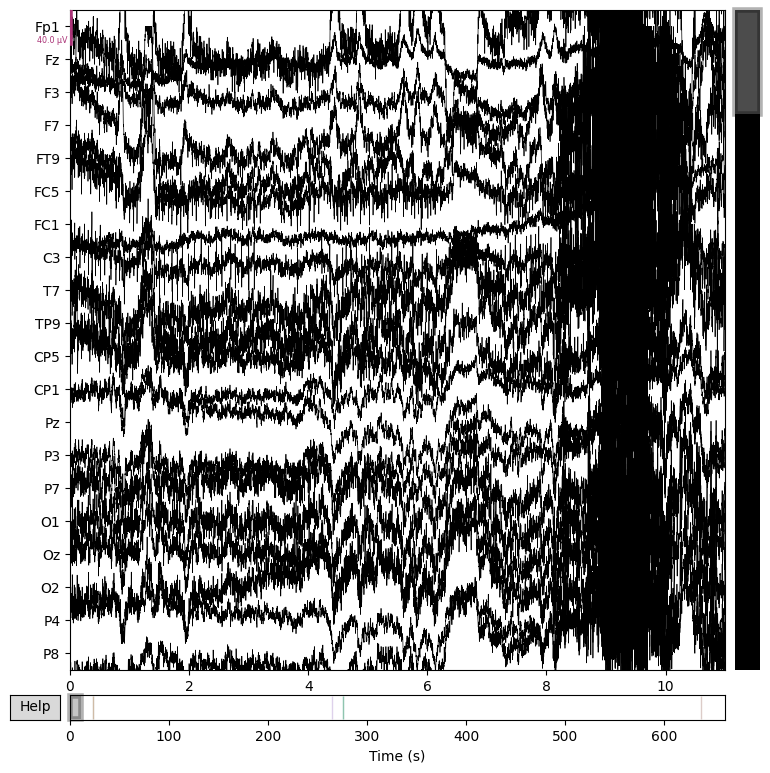

Figure(800x800)


In [ ]:
raw = load_rest_eeg("../data/ds004796/sub-01/eeg/sub-01_task-rest_eeg.vhdr", preload=True)

print(raw.info)
print(raw.annotations)
fig = raw.plot(n_channels=20, duration=11)
print(fig)
fig.savefig("../figures/exploratory/sub-01_rest_raw_eeg.png", dpi=300, bbox_inches="tight")


In [121]:
# Crop the resting-state recording into eyes-open and eyes-closed segments
raw_eyes_open, raw_eyes_closed, markers = crop_rest_conditions(raw)

eyes_open_start = markers["eyes_open_start"] # start of eyes open
eyes_open_end = markers["eyes_open_end"] # end of eyes open ?
eyes_closed_start = markers["eyes_closed_start"] # start of eyes closed
eyes_closed_end = markers["eyes_closed_end"] # end of eyes closed ?

print(f"Eyes-open segment: {eyes_open_start:.3f}s to {eyes_open_end:.3f}s ({eyes_open_end - eyes_open_start:.1f}s)")
print(f"Eyes-closed segment: {eyes_closed_start:.3f}s to {eyes_closed_end:.3f}s ({eyes_closed_end - eyes_closed_start:.1f}s)")


Eyes-open segment: 23.323s to 264.701s (241.4s)
Eyes-closed segment: 276.067s to 637.358s (361.3s)


Effective window size : 2.048 (s)
Effective window size : 2.048 (s)


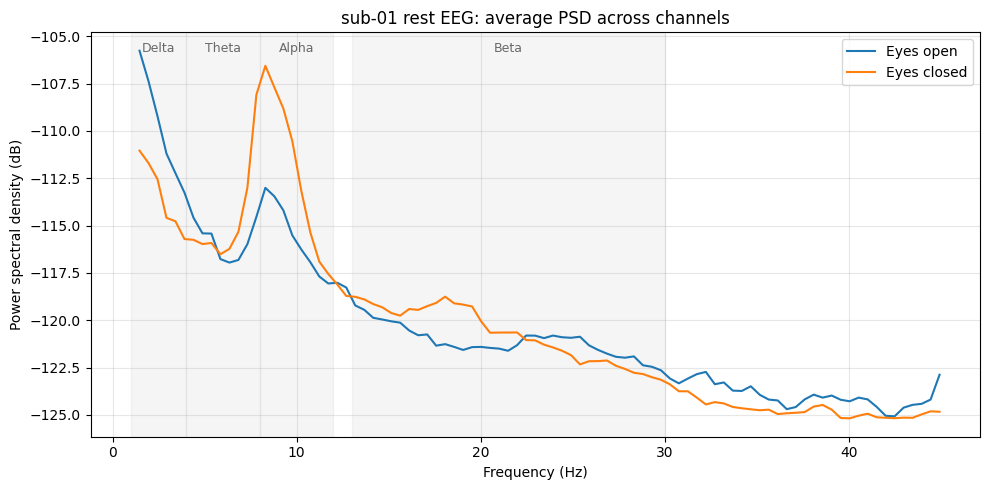

In [184]:
# Compare average PSD for eyes-open vs eyes-closed segments
fig, ax = plot_psd_comparison(
    raw_eyes_open,
    raw_eyes_closed,
    fmin=1,
    fmax=45,
    title="sub-01 rest EEG: average PSD across channels",
    save_path="../figures/exploratory/sub-01_rest_psd_open_vs_closed.png",
)
plt.show()


Effective window size : 2.048 (s)
Effective window size : 2.048 (s)


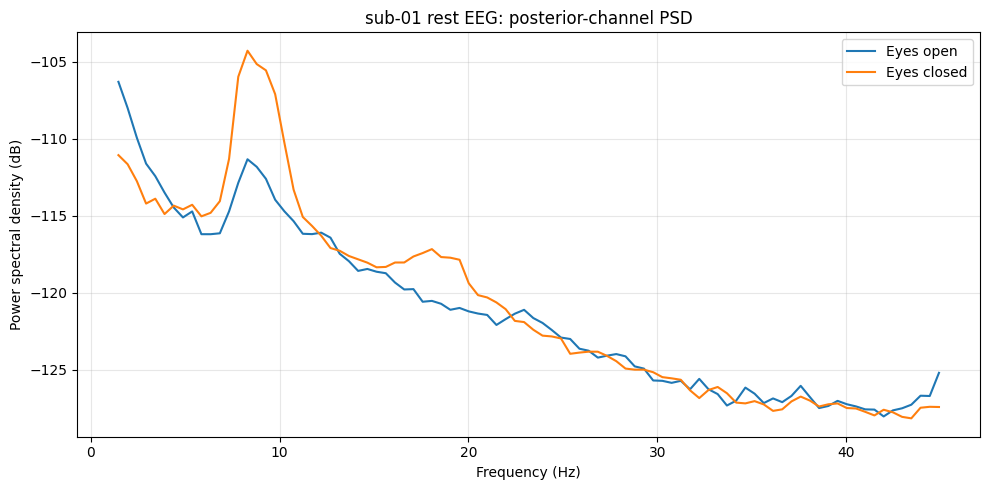

In [ ]:
# Compare PSD for posterior channels only, where resting alpha is usually strongest
fig, ax = plot_psd_comparison(
    raw_eyes_open,
    raw_eyes_closed,
    fmin=1,
    fmax=45,
    title="sub-01 rest EEG: posterior-channel PSD",
    save_path="../figures/exploratory/sub-01_rest_psd_posterior_open_vs_closed.png",
    posterior_only=True,
)
plt.show()


PSDs look as expected
- Overall shape: power higher at low freqs and drops as freq increases
- Alpha peak (8 to 12 Hz) is stronger in eyes closed than eyes open, and strongest in posterior electrodes

Note: posterior channels included were P3, Pz, P4, 01, Oz, O2

### Further analysis of subjects (2/3/4)


## sub-02
Extracting parameters from ../data/ds004796/sub-02/eeg/sub-02_task-rest_eeg.vhdr...
Setting channel info structure...
Reading 0 ... 637719  =      0.000 ...   637.719 secs...
<Annotations | 6 segments: Stimulus/S 1 (2), Stimulus/S 2 (1), Stimulus/S ...>


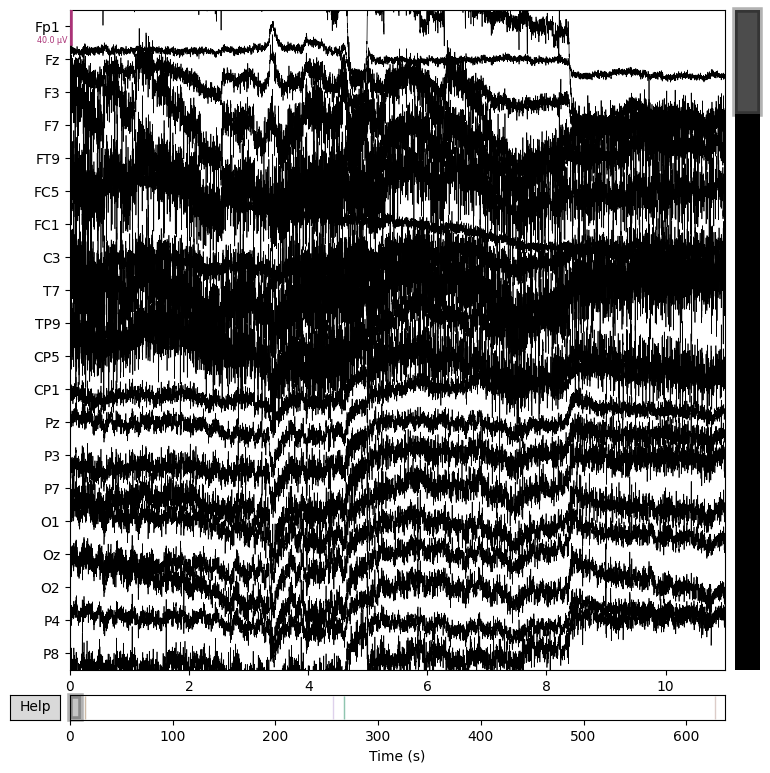

Figure(800x800)

## sub-03
Extracting parameters from ../data/ds004796/sub-03/eeg/sub-03_task-rest_eeg.vhdr...
Setting channel info structure...
Reading 0 ... 670759  =      0.000 ...   670.759 secs...
<Annotations | 6 segments: Stimulus/S 1 (2), Stimulus/S 2 (1), Stimulus/S ...>


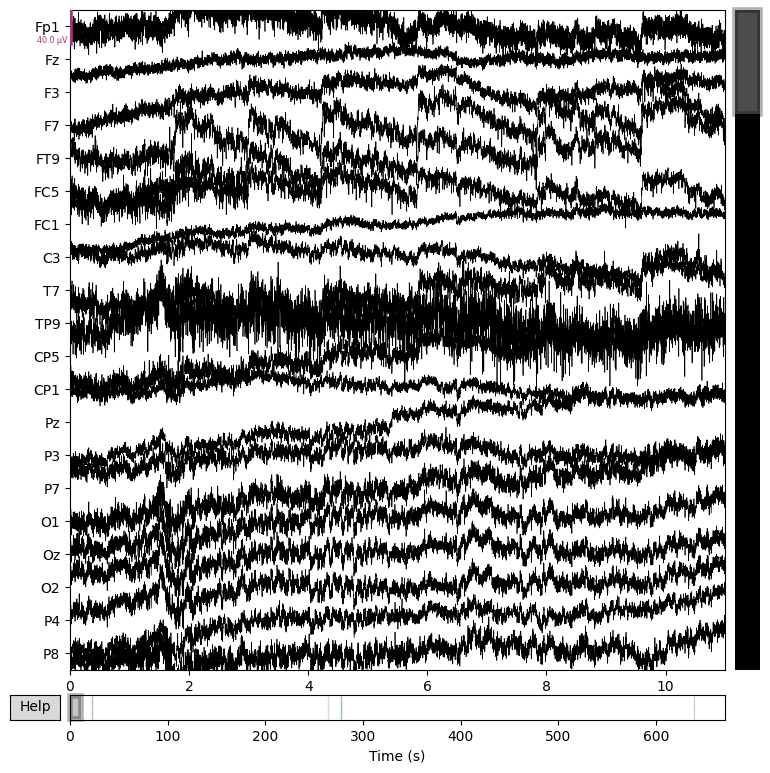

Figure(800x800)

## sub-04
Extracting parameters from ../data/ds004796/sub-04/eeg/sub-04_task-rest_eeg.vhdr...
Setting channel info structure...
Reading 0 ... 704099  =      0.000 ...   704.099 secs...
<Annotations | 6 segments: Stimulus/S 1 (2), Stimulus/S 2 (1), Stimulus/S ...>


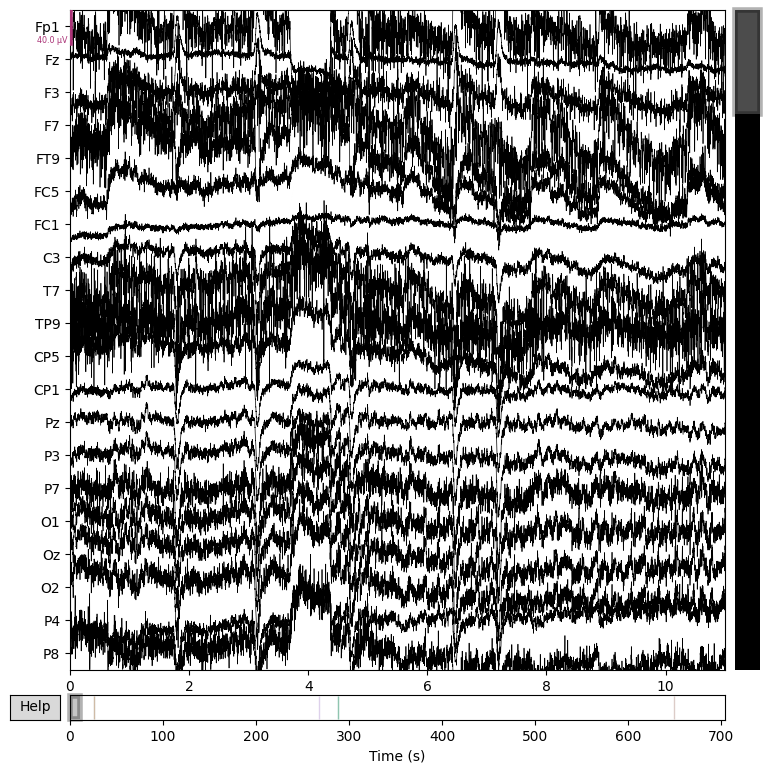

Figure(800x800)


In [182]:
subjects = ["sub-02", "sub-03", "sub-04"]

raw_subjects = {}

for sub in subjects:
    print(f"\n## {sub}")

    raw = load_rest_eeg(f"../data/ds004796/{sub}/eeg/{sub}_task-rest_eeg.vhdr", preload=True)
    raw_subjects[sub] = raw

    print(raw.annotations)

    fig = raw.plot(n_channels=20, duration=11)
    print(fig)
    fig.savefig(f"../figures/exploratory/{sub}_rest_raw_eeg.png", dpi=300, bbox_inches="tight")


## sub-02
Eyes-open segment: 14.929s to 256.290s (241.4s)
Eyes-closed segment: 267.090s to 628.381s (361.3s)
Effective window size : 2.048 (s)
Effective window size : 2.048 (s)


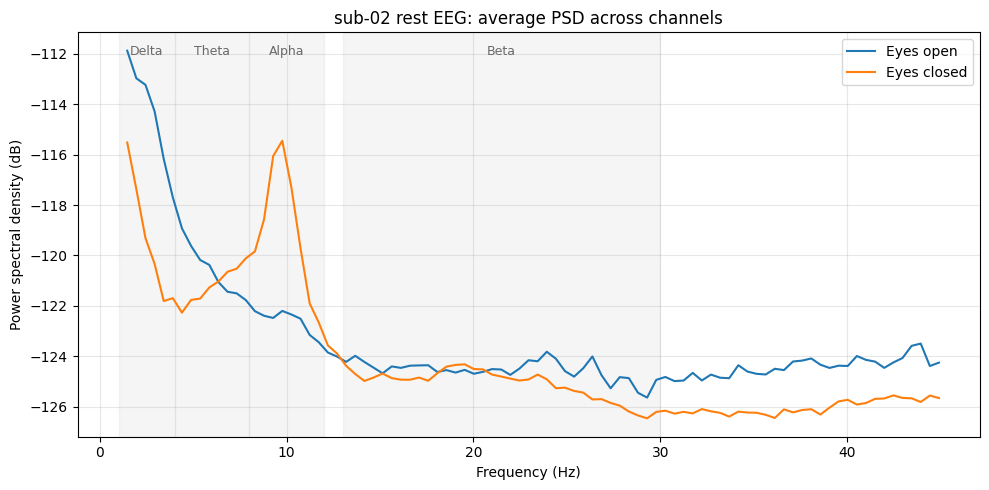


## sub-03
Eyes-open segment: 22.436s to 264.297s (241.9s)
Eyes-closed segment: 277.480s to 638.771s (361.3s)
Effective window size : 2.048 (s)
Effective window size : 2.048 (s)


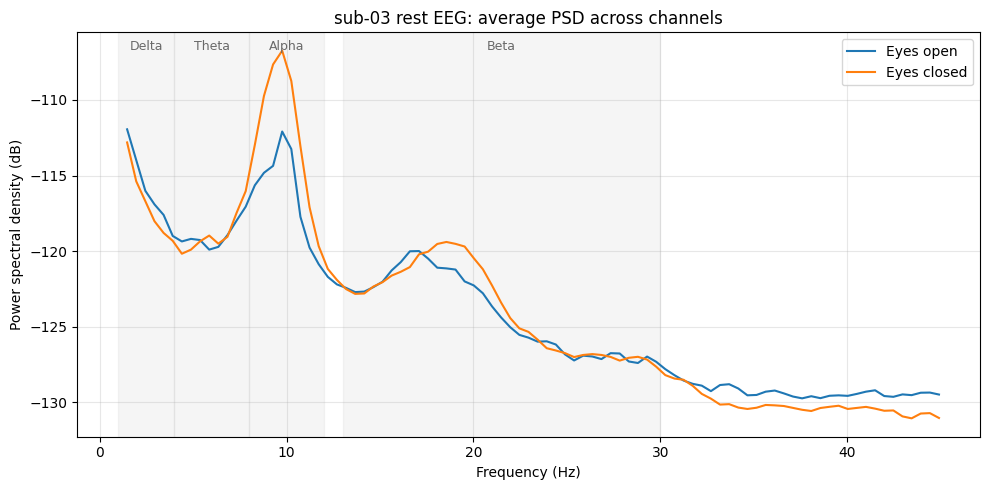


## sub-04
Eyes-open segment: 25.737s to 267.631s (241.9s)
Eyes-closed segment: 288.347s to 649.638s (361.3s)
Effective window size : 2.048 (s)
Effective window size : 2.048 (s)


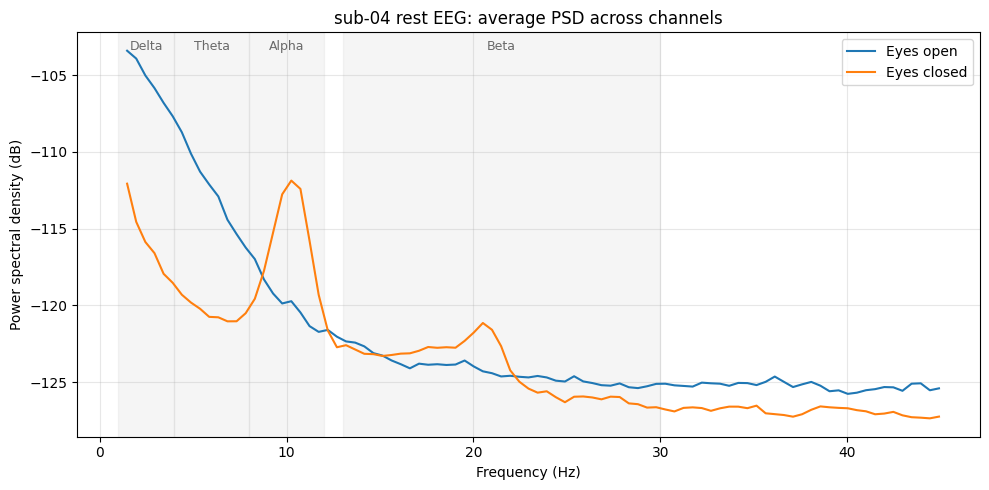

In [188]:
subjects = ["sub-02", "sub-03", "sub-04"]

cropped_subjects = {}

for sub in subjects:
    print(f"\n## {sub}")

    raw_eyes_open, raw_eyes_closed, markers = crop_rest_conditions(raw_subjects[sub])
    cropped_subjects[sub] = {
        "eyes_open": raw_eyes_open,
        "eyes_closed": raw_eyes_closed,
        "markers": markers,
    }

    eyes_open_start = markers["eyes_open_start"]
    eyes_open_end = markers["eyes_open_end"]
    eyes_closed_start = markers["eyes_closed_start"]
    eyes_closed_end = markers["eyes_closed_end"]

    print(
        f"Eyes-open segment: {eyes_open_start:.3f}s to {eyes_open_end:.3f}s "
        f"({eyes_open_end - eyes_open_start:.1f}s)")
    print(
        f"Eyes-closed segment: {eyes_closed_start:.3f}s to {eyes_closed_end:.3f}s "
        f"({eyes_closed_end - eyes_closed_start:.1f}s)")

    fig, ax = plot_psd_comparison(
        raw_eyes_open,
        raw_eyes_closed,
        fmin=1,
        fmax=45,
        title=f"{sub} rest EEG: average PSD across channels",
        save_path=f"../figures/exploratory/{sub}_rest_psd_open_vs_closed.png",
      )
    plt.show()



## sub-02 posterior PSD
Effective window size : 2.048 (s)
Effective window size : 2.048 (s)


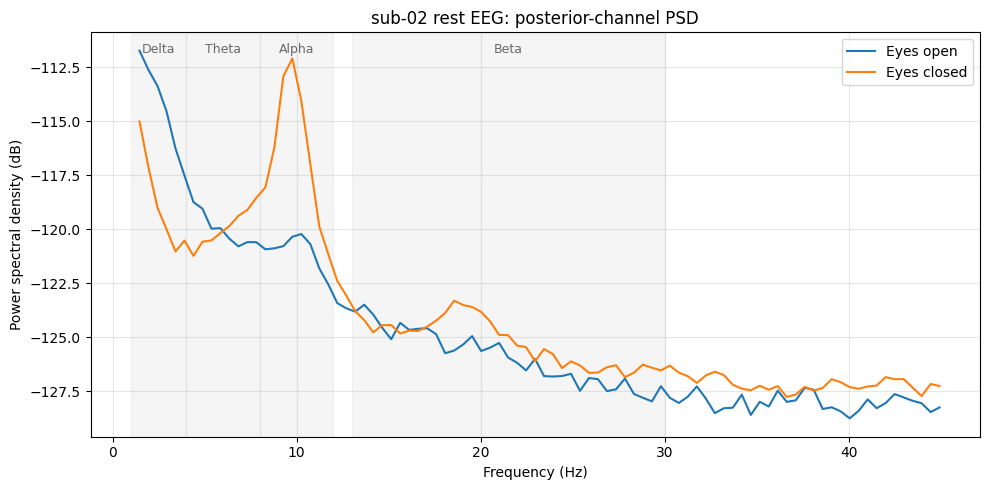


## sub-03 posterior PSD
Effective window size : 2.048 (s)
Effective window size : 2.048 (s)


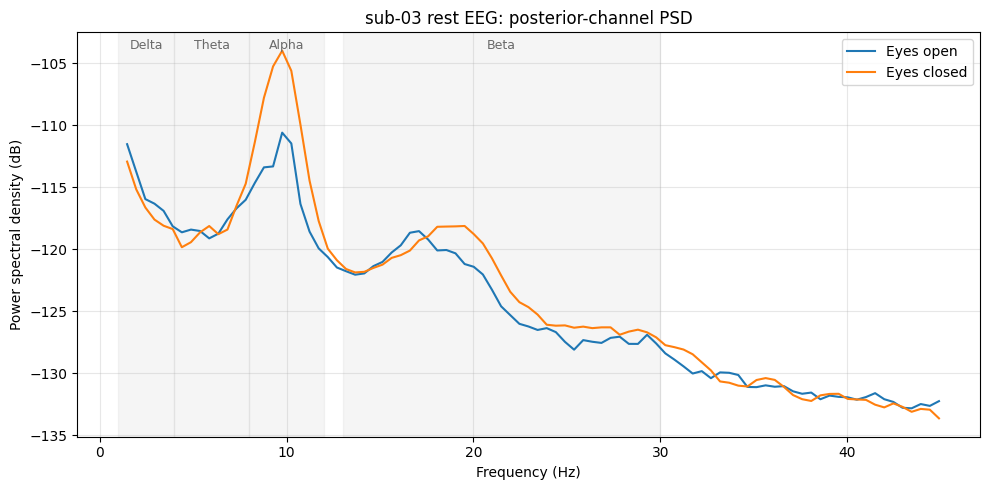


## sub-04 posterior PSD
Effective window size : 2.048 (s)
Effective window size : 2.048 (s)


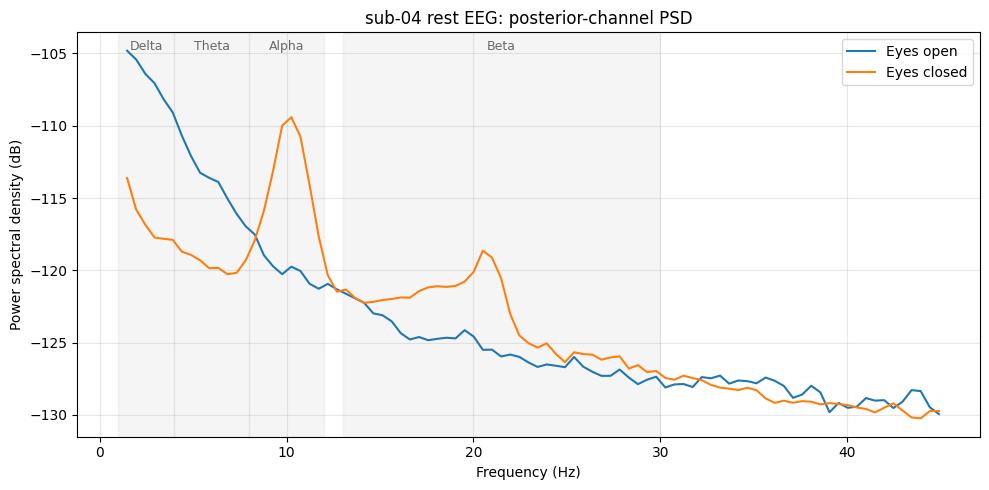

In [190]:
for sub in subjects:
    print(f"\n## {sub} posterior PSD")

    raw_eyes_open = cropped_subjects[sub]["eyes_open"]
    raw_eyes_closed = cropped_subjects[sub]["eyes_closed"]

    fig, ax = plot_psd_comparison(
        raw_eyes_open,
        raw_eyes_closed,
        fmin=1,
        fmax=45,
        title=f"{sub} rest EEG: posterior-channel PSD",
        save_path=f"../figures/exploratory/{sub}_rest_psd_posterior_open_vs_closed.png",
        posterior_only=True,
    )
    plt.show()

## Summary of initial resting EEG exploration

Initial resting-state EEG exploration was conducted on sub-01 and extended to sub-02, sub-03, and sub-04 to assess whether the same workflow could be applied consistently across multiple participants. For each subject, the resting-state BrainVision recording was loaded, the event structure was used to separate eyes-open and eyes-closed segments, and power spectral density (PSD) was compared across conditions for both all channels and posterior channels only.

Across all four subjects, the expected physiological pattern was observed: alpha-band power was higher in the eyes-closed condition than in the eyes-open condition, including in posterior electrodes where resting alpha is typically strongest. This suggests that the event parsing and condition segmentation are behaving plausibly and that the recordings capture a recognisable resting-state EEG signature.

At the same time, visible differences in raw signal quality and artifact burden were observed across subjects. While the overall eyes-open versus eyes-closed pattern was consistent, the recordings varied in noisiness and likely contain subject-specific artifacts that should be addressed before any downstream feature extraction or quantitative comparison. These observations support the next step of developing a
preprocessing workflow that can be applied consistently across subjects before moving to more formal analysis.



## Next steps

  - Initial resting EEG exploration has now been completed for sub-01 to sub-04.
  - The event structure was sufficient to separate eyes-open and eyes-closed segments across these subjects.
  - All explored subjects showed the expected increase in alpha-band power in the eyes-closed condition.
  - Raw signal quality and artifact burden varied across subjects, indicating that preprocessing will be necessary before further analysis.
  - The next step will be to begin a separate preprocessing notebook / Rmd focused on building a consistent resting-state EEG cleaning pipeline.
  - That preprocessing workflow will then be tested on this small set of subjects before being extended to the wider cohort.